# Notebook 4: LSTM-SNP with Fuzzy Output Layer

**Dataset**: S&P 500

## Description
This notebook implements a **fuzzy output layer** for the LSTM-SNP model. The internal 
LSTM-SNP str1. ucture is kept completely intact. The final Dense(1) layer is replaced with a 
fuzzy inference system that takes the RNN hidden state h(t) and produces the prediction 
through Takagi-Sugeno rules.

The fuzzy output layer aggregates h(t) into 2 summary features via mean-pooling, then applies 
4 rules with fixed Gaussian membership functions and trainable consequent parameters.

## Theory: Fuzzy Output Layer

### LSTM-SNP Cell (Unchanged)
All internal LSTM-SNP equations remain exactly as in the baseline.

### Fuzzy Output Computation
The Dense(1) output layer is replaced with fuzzy inference:

**Input**: $h(t) \in \mathbb{R}^{units}$ from the RNN

**Feature Aggregation**: Mean-pooling into 2 summary statistics:
- $s_1 = \text{mean}(h_{1:units/2})$
- $s_2 = \text{mean}(h_{units/2+1:units})$

**Membership Functions** (Fixed Gaussian):
- $\mu_{low}(s) = \exp\left(-\frac{(s-(-1))^2}{2 \cdot 0.5^2}\right)$
- $\mu_{high}(s) = \exp\left(-\frac{(s-(+1))^2}{2 \cdot 0.5^2}\right)$

**4 Takagi-Sugeno Rules** (trainable consequents):
$y_i = a_i s_1 + b_i s_2 + c_i$

**Defuzzification**: $\hat{y} = \frac{\sum_i w_i y_i}{\sum_i w_i}$

## Model Architecture & Implementation

In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.0.2


### LSTM-SNP Cell

In [2]:
# ============================================================
# LSTM-SNP Cell (Original — Unmodified)
# ============================================================

class LSTMSNPCell(layers.Layer):
    """
    LSTM-SNP Cell: A long short-term memory model inspired from
    spiking neural P systems.

    Gates:
      r(t) = ρ(W_r x(t) + U_r u(t-1) + b_r)   [reset]
      c(t) = ρ(W_c x(t) + U_c u(t-1) + b_c)   [consumption]
      o(t) = ρ(W_o x(t) + U_o u(t-1) + b_o)   [output/generation]
      a(t) = f(W_a x(t) + U_a u(t-1) + b_a)   [generated spikes]

    State update:
      u(t) = r(t) * u(t-1) - c(t) * a(t)
      h(t) = o(t) * a(t)

    ρ = hard_sigmoid, f = tanh
    """
    def __init__(self, units,
                 activation='tanh',
                 recurrent_activation='hard_sigmoid',
                 **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units

        self.activation = tf.keras.activations.get(activation)
        self.recurrent_activation = tf.keras.activations.get(recurrent_activation)

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.kernel = self.add_weight(
            shape=(input_dim, self.units * 4),
            initializer='glorot_uniform',
            name='kernel'
        )
        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units * 4),
            initializer='orthogonal',
            name='recurrent_kernel'
        )
        self.bias = self.add_weight(
            shape=(self.units * 4,),
            initializer='zeros',
            name='bias'
        )

    def call(self, inputs, states):
        u_tm1 = states[0]

        z = tf.matmul(inputs, self.kernel) + \
            tf.matmul(u_tm1, self.recurrent_kernel) + self.bias

        z0 = z[:, :self.units]
        z1 = z[:, self.units:2*self.units]
        z2 = z[:, 2*self.units:3*self.units]
        z3 = z[:, 3*self.units:]

        r = self.recurrent_activation(z0)  # reset
        c = self.recurrent_activation(z1)  # consumption
        o = self.recurrent_activation(z2)  # output/generation
        a = self.activation(z3)            # generated spikes

        u = r * u_tm1 - c * a  # internal state
        h = o * a              # output

        return h, [u]

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
        })
        return config

### Fuzzy Output Layer

In [3]:
# ============================================================
# Fuzzy Output Layer
# Replaces Dense(1) with fuzzy inference.
#
# Takes RNN output h(t) ∈ R^units, produces scalar prediction.
# Aggregates h(t) into 2 summary features via mean-pooling:
#   s1 = mean(h[:units//2])
#   s2 = mean(h[units//2:])
#
# Then applies 4 Takagi-Sugeno rules.
# Fixed Gaussian MFs. Trainable consequent parameters.
# ============================================================

class FuzzyOutputLayer(layers.Layer):
    """
    Fuzzy output layer: replaces Dense(1).
    Input: h(t) from RNN (shape: [batch, units])
    Output: scalar prediction (shape: [batch, 1])
    """
    def __init__(self, units_in, **kwargs):
        super().__init__(**kwargs)
        self.units_in = units_in
        self.mu_low = -1.0
        self.mu_high = 1.0
        self.sigma = 0.5

    def build(self, input_shape):
        # 4 rules, each with 3 consequent params (a, b, c)
        # y_i = a_i * s1 + b_i * s2 + c_i
        self.rule_a = self.add_weight(shape=(4,), initializer='glorot_uniform', name='rule_a')
        self.rule_b = self.add_weight(shape=(4,), initializer='glorot_uniform', name='rule_b')
        self.rule_c = self.add_weight(shape=(4,), initializer='zeros', name='rule_c')

    def _gaussian_mf(self, x, center):
        return tf.exp(-tf.square(x - center) / (2.0 * self.sigma ** 2))

    def call(self, inputs):
        half = self.units_in // 2
        # Aggregate to 2 summary features
        s1 = tf.reduce_mean(inputs[:, :half], axis=-1, keepdims=True)  # [batch, 1]
        s2 = tf.reduce_mean(inputs[:, half:], axis=-1, keepdims=True)  # [batch, 1]

        # Membership degrees
        mu_low_s1 = self._gaussian_mf(s1, self.mu_low)
        mu_high_s1 = self._gaussian_mf(s1, self.mu_high)
        mu_low_s2 = self._gaussian_mf(s2, self.mu_low)
        mu_high_s2 = self._gaussian_mf(s2, self.mu_high)

        # Rule weights
        w1 = mu_low_s1 * mu_low_s2
        w2 = mu_low_s1 * mu_high_s2
        w3 = mu_high_s1 * mu_low_s2
        w4 = mu_high_s1 * mu_high_s2

        # Consequent outputs
        y1 = self.rule_a[0] * s1 + self.rule_b[0] * s2 + self.rule_c[0]
        y2 = self.rule_a[1] * s1 + self.rule_b[1] * s2 + self.rule_c[1]
        y3 = self.rule_a[2] * s1 + self.rule_b[2] * s2 + self.rule_c[2]
        y4 = self.rule_a[3] * s1 + self.rule_b[3] * s2 + self.rule_c[3]

        # Defuzzification
        numerator = w1 * y1 + w2 * y2 + w3 * y3 + w4 * y4
        denominator = w1 + w2 + w3 + w4 + 1e-8

        return numerator / denominator

    def get_config(self):
        config = super().get_config()
        config.update({'units_in': self.units_in})
        return config

### Build Model

In [4]:
# ============================================================
# Model Construction: LSTM-SNP with Fuzzy Output Layer
# LSTMSNPCell is UNMODIFIED.
# Dense(1) is replaced by FuzzyOutputLayer.
# ============================================================

def build_model(input_dim, units, batch_size):
    cell = LSTMSNPCell(units)
    rnn = layers.RNN(cell, return_sequences=False, stateful=True)

    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x = rnn(inputs)
    outputs = FuzzyOutputLayer(units_in=units)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [5]:
# Quick model check
model = build_model(input_dim=1, units=8, batch_size=1)
model.summary()

I0000 00:00:1787834061.686171   61835 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787834061.688518   61835 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (1, 1, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (1, 8)                 │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fuzzy_output_layer              │ (1, 1)                 │            12 │
│ (FuzzyOutputLayer)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332 (1.30 KB)

 Trainable params: 332 (1.30 KB)

 Non-trainable params: 0 (0.00 B)

## Data Pipeline — S&P 500

In [6]:
import os
for f in os.listdir('/kaggle/input/datasets/sassyaws123456789/sp500-csv/'):
    print(f)

sp500.csv


In [7]:
# ============================================================
# 1. Load Time Series Data
# ============================================================
series = pd.read_csv(
    '/kaggle/input/datasets/sassyaws123456789/sp500-csv/sp500.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

original_raw_values = series.values.flatten()
print(f"Base data shape: {original_raw_values.shape}")
print(f"Base data first 5 values: {original_raw_values[:5]}")

Base data shape: (251,)
Base data first 5 values: [2038.199951 2013.780029 2011.709961 1985.319946 1945.969971]


In [8]:
# ============================================================
# 2. First-Order Differencing
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

In [9]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

In [10]:
# ============================================================
# 4 & 5. Train-Test Split and Feature Scaling
# ============================================================
# NOTE: The actual application of differencing, splitting (last 60 for test), 
# and scaling is performed inside the Gaussian Noise loop below to prevent data leakage.
print("Split protocol: Last 60 samples for Testing, remainder for Training.")

Split protocol: Last 60 samples for Testing, remainder for Training.


In [11]:
# ============================================================
# 6. Reshape for RNN Input
# ============================================================
print("Reshape protocol: (samples, time_steps, features)")

Reshape protocol: (samples, time_steps, features)


## Training Loop

In [12]:
# ============================================================
# Gaussian Noise Evaluation + 60-Run Experiment Protocol (Keras)
# ============================================================
s_x = np.std(original_raw_values)
noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

for lam in noise_levels:
    sigma = lam * s_x
    print("\n" + "="*80)
    print(f"EVALUATING NOISE LEVEL: {lam*100:.1f}% (lambda={lam}, sigma={sigma:.6f})")
    print("="*80 + "\n")
    
    np.random.seed(42)
    tf.random.set_seed(42)
    noise = np.random.normal(0, sigma, size=original_raw_values.shape)
    raw_values = original_raw_values + noise
    
    # 2. Difference
    diff_values = difference(raw_values, 1)
    # 3. Supervised
    supervised = timeseries_to_supervised(diff_values, 1)
    # 4. Split (Last 60 for test, no validation)
    train, test = supervised[:-60], supervised[-60:]
    # 5. Scale
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train)
    train_scaled = scaler.transform(train)
    test_scaled = scaler.transform(test)
    # 6. Reshape
    X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
    
    all_rmse = []
    all_mse = []
    all_nmse = []
    all_predictions = []
    all_losses = []
    
    # 60 RUNS, 100 EPOCHS
    for run in range(60):
        print(f'\n===== RUN {run+1}/60 [Noise {lam*100:.1f}%] =====')

        np.random.seed(run)
        tf.random.set_seed(run)

        tf.keras.backend.clear_session()
        model = build_model(input_dim=1, units=8, batch_size=1)

        # Set consumption gate (c) bias to 1.0 (unit forget bias)
        rnn_layer = model.layers[1]
        cell = rnn_layer.cell
        weights = cell.get_weights()
        bias = weights[2].copy()
        bias[8:16] = 1.0  # units=8, bias[units:2*units]
        weights[2] = bias
        cell.set_weights(weights)

        run_losses = []
        for epoch in range(100):
            history = model.fit(
                X_train, y_train,
                epochs=1, batch_size=1,
                verbose=0, shuffle=False
            )
            run_losses.append(history.history['loss'][0])
            if (epoch+1) % 10 == 0:
                print(f'  Epoch {epoch+1}/100 completed, Loss: {history.history["loss"][0]:.6f}')
            rnn_layer.reset_states()

        all_losses.append(run_losses)
        print(f'Training complete for run {run+1}')

        # Warm-up: condition hidden states on training data
        train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
        model.predict(train_reshaped, batch_size=1, verbose=0)

        # Test predictions (single-step)
        predictions = []
        for i in range(len(test_scaled)):
            X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
            X_input = X.reshape(1, 1, len(X))
            yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]
            
            # Invert scaling
            new_row = [x for x in X] + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]
            
            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)
            expected = raw_values[len(train) + i + 1]

        # Compute metrics
        actual = raw_values[-len(predictions):]
        rmse = sqrt(mean_squared_error(actual, predictions))
        mse = mean_squared_error(actual, predictions)
        meanV = np.mean(actual)
        dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
        nmse = mse / np.power(dominator, 2)
        all_rmse.append(rmse)
        all_mse.append(mse)
        all_nmse.append(nmse)
        all_predictions.append(predictions)
        print(f'Run {run+1} Metrics — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')

    # End of 60 runs for this noise level - save best run data
    best_idx = np.argmin(all_rmse)
    _molab_results.append([lam, all_rmse[best_idx], all_mse[best_idx], all_nmse[best_idx], 
                           all_predictions[best_idx], all_losses[best_idx], raw_values])
    print(f"\nBest run for {lam*100:.1f}% noise: Run {best_idx+1} (RMSE: {all_rmse[best_idx]:.6f})")


EVALUATING NOISE LEVEL: 0.0% (lambda=0.0, sigma=0.000000)


===== RUN 1/60 [Noise 0.0%] =====


I0000 00:00:1787834066.853404   61879 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Epoch 10/100 completed, Loss: 0.056801
  Epoch 20/100 completed, Loss: 0.056646
  Epoch 30/100 completed, Loss: 0.056471
  Epoch 40/100 completed, Loss: 0.056261
  Epoch 50/100 completed, Loss: 0.056033
  Epoch 60/100 completed, Loss: 0.055784
  Epoch 70/100 completed, Loss: 0.055480
  Epoch 80/100 completed, Loss: 0.055109
  Epoch 90/100 completed, Loss: 0.054699
  Epoch 100/100 completed, Loss: 0.054274
Training complete for run 1
Run 1 Metrics — RMSE: 11.346911, MSE: 128.752386, NMSE: 0.0007806857

===== RUN 2/60 [Noise 0.0%] =====
  Epoch 10/100 completed, Loss: 0.056692
  Epoch 20/100 completed, Loss: 0.056554
  Epoch 30/100 completed, Loss: 0.056293
  Epoch 40/100 completed, Loss: 0.055816
  Epoch 50/100 completed, Loss: 0.055066
  Epoch 60/100 completed, Loss: 0.054251
  Epoch 70/100 completed, Loss: 0.053520
  Epoch 80/100 completed, Loss: 0.052713
  Epoch 90/100 completed, Loss: 0.051993
  Epoch 100/100 completed, Loss: 0.051504
Training complete for run 2
Run 2 Metrics — RM

## Results


RESULTS FOR NOISE LEVEL: 0.0%
=== Best Run Metrics ===
RMSE: 10.934895
MSE:  119.571934
NMSE: 0.0007087619


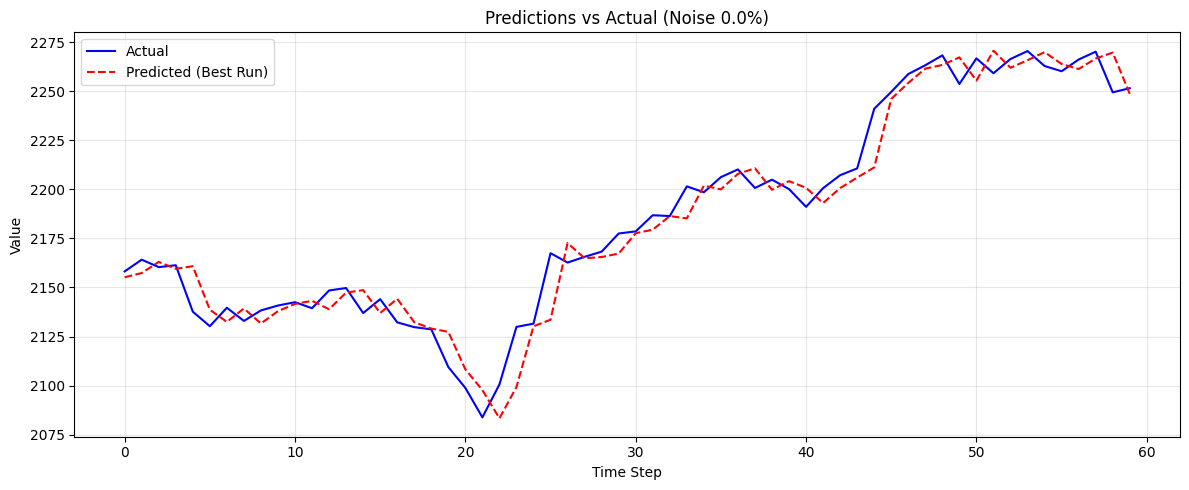

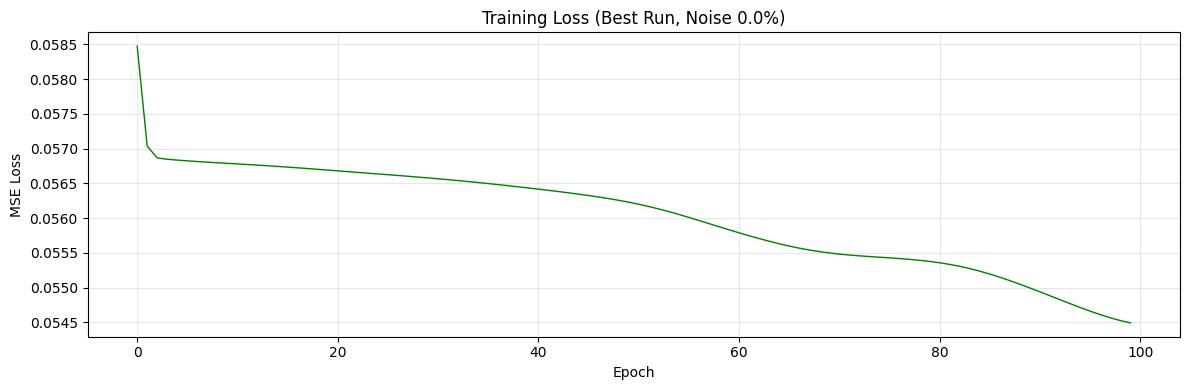


RESULTS FOR NOISE LEVEL: 0.5%
=== Best Run Metrics ===
RMSE: 10.842314
MSE:  117.555775
NMSE: 0.0006874163


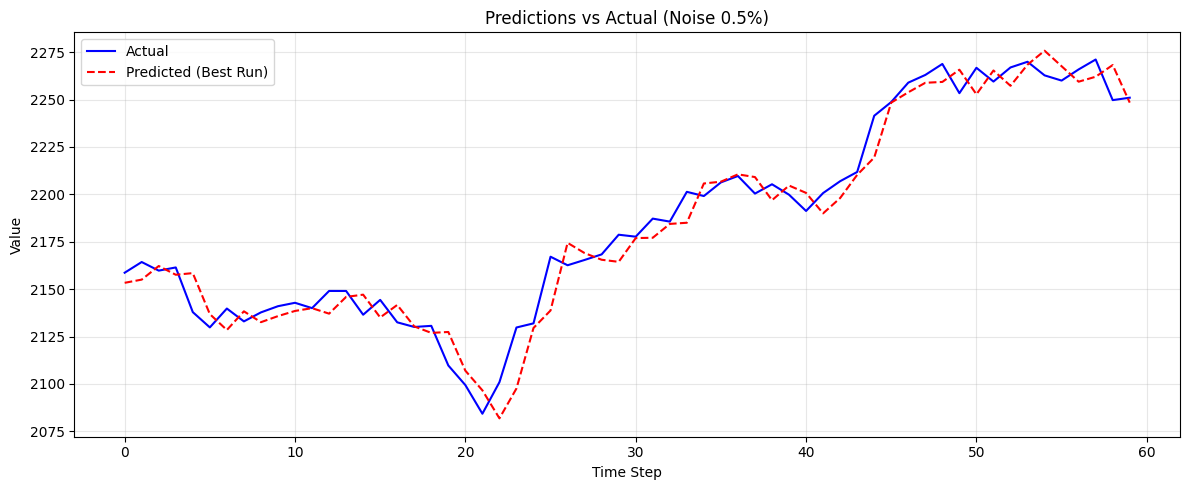

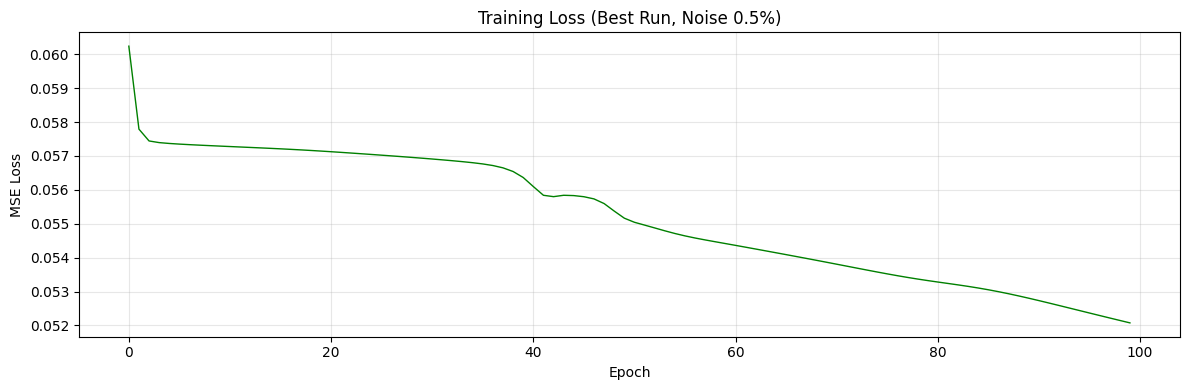


RESULTS FOR NOISE LEVEL: 5.0%
=== Best Run Metrics ===
RMSE: 13.158825
MSE:  173.154676
NMSE: 0.0010942852


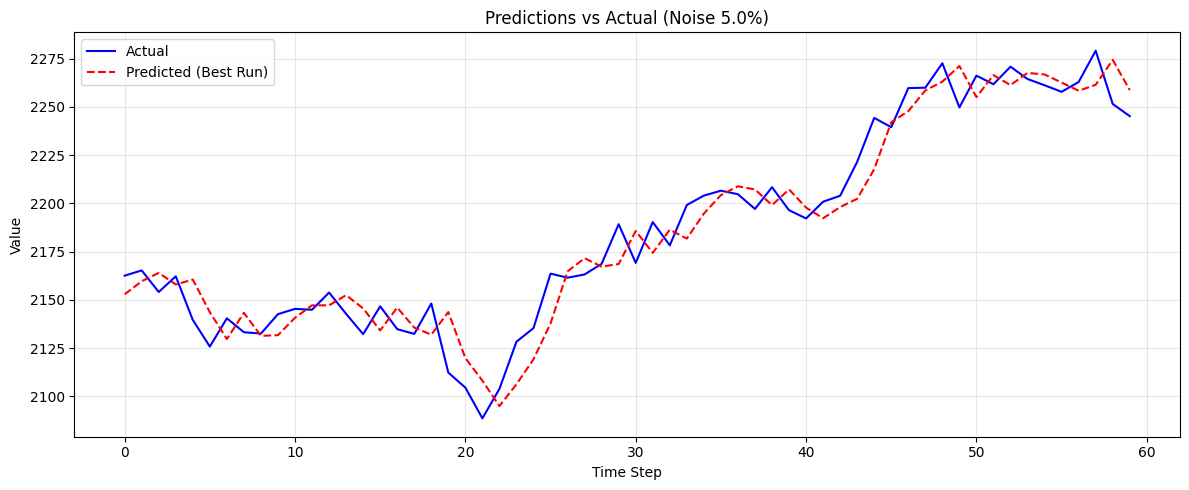

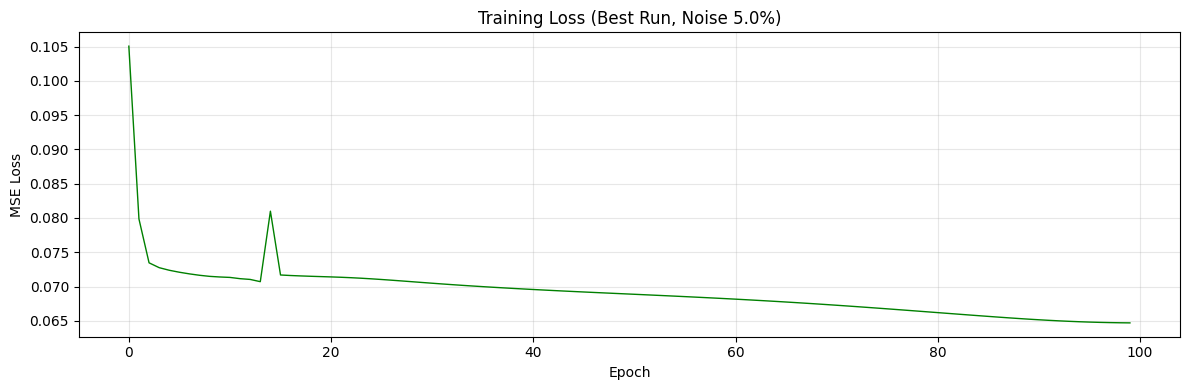


RESULTS FOR NOISE LEVEL: 10.0%
=== Best Run Metrics ===
RMSE: 17.757079
MSE:  315.313870
NMSE: 0.0020628466


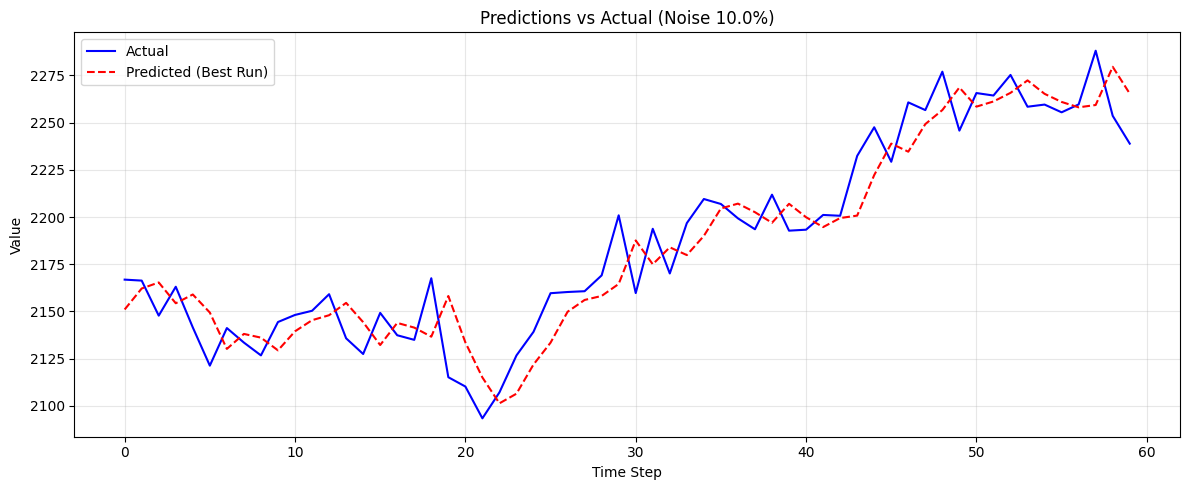

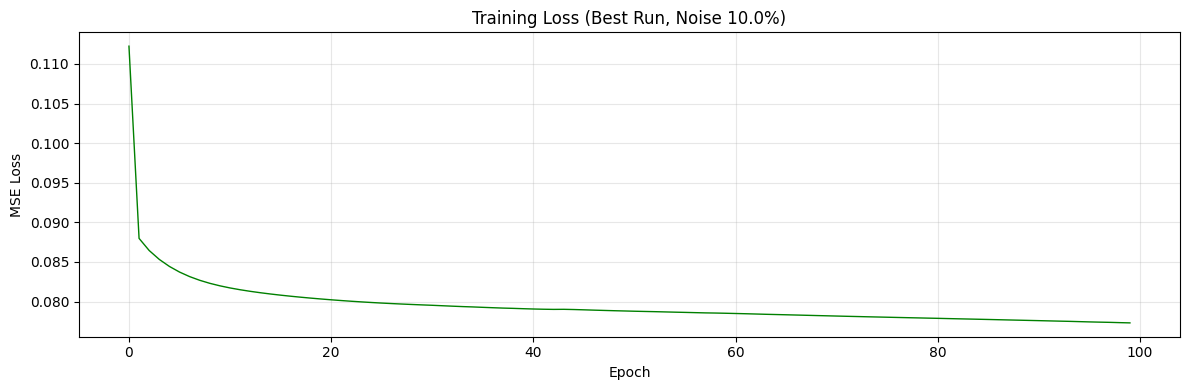


FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
|   Noise Level (lambda) |    RMSE |     MSE |        NMSE |
|------------------------|---------|---------|-------------|
|                  0     | 10.9349 | 119.572 | 0.000708762 |
|                  0.005 | 10.8423 | 117.556 | 0.000687416 |
|                  0.05  | 13.1588 | 173.155 | 0.00109429  |
|                  0.1   | 17.7571 | 315.314 | 0.00206285  |


In [13]:
# ============================================================
# Final Metrics Summary & Plots per Noise Level
# ============================================================
from tabulate import tabulate

for lam, best_rmse, best_mse, best_nmse, best_predictions, best_losses, raw_values_for_plot in _molab_results:
    print("\n" + "="*80)
    print(f"RESULTS FOR NOISE LEVEL: {lam*100:.1f}%")
    print("="*80)
    
    print('=== Best Run Metrics ===')
    print(f'RMSE: {best_rmse:.6f}')
    print(f'MSE:  {best_mse:.6f}')
    print(f'NMSE: {best_nmse:.10f}')
    
    actual = raw_values_for_plot[-60:]
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
    plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
             linewidth=1.5, linestyle='--')
    plt.title(f'Predictions vs Actual (Noise {lam*100:.1f}%)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(best_losses, color='green', linewidth=1.0)
    plt.title(f'Training Loss (Best Run, Noise {lam*100:.1f}%)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Global summary table
print("\n" + "="*80)
print("FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS")
print("="*80)
df_res = pd.DataFrame([r[:4] for r in _molab_results], columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))

## Observations

### Gaussian Noise robustness on S&P 500

**Run the notebook to populate results.**